In [1]:
!pip install statsmodels matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
  Using cached statsmodels-0.14.6-cp313-cp313-win_amd64.whl.metadata (9.8 kB)
  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
Using cached statsmodels-0.14.6-cp313-cp313-win_amd64.whl (9.5 MB)
Using cached patsy-1.0.2-py2.py3-none-any.whl (233 kB)

   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\geova\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np

# Carregar os dados
df = pd.read_csv("conjoint_survey_resp_v1.csv")

# Verificar se carregou corretamente
print(df.shape)  # esperado: (840, 17)
print(df.head(4))

(840, 17)
   Unnamed: 0  resp.id  ques       alt             Price        Brand  \
0           0        1     1  Option 1     Value(3€-10€)        Cavit   
1           1        1     1  Option 2  Popular(10€-15€)  Mezzacorona   
2           2        1     1  Option 3  Premium(15€-30€)      Ferrari   
3           3        1     1  Option 4  Popular(10€-15€)      Ferrari   

  Type of Wine Percentage of Alcohol Aging time of Wine  Age     Sex  \
0   White wine                 5.5 %            3 years    1  Female   
1   White wine                  18 %            1 year     1  Female   
2    Rose wine                  12 %            1 year     1  Female   
3    Rose wine                  18 %            4 years    1  Female   

  Employment status Education Ethnicity Social Platforms Physical Activities  \
0           Student   Masters    German        Instagram            Moderate   
1           Student   Masters    German        Instagram            Moderate   
2           Student   M

###  Remover coluna desnecessária

In [3]:
df = df.drop(columns=["Unnamed: 0"])

#### Remover espaços extras:

In [4]:
df["Aging time of Wine"] = df["Aging time of Wine"].str.strip()
df["Percentage of Alcohol"] = df["Percentage of Alcohol"].str.strip()

###  Verificar: 

In [5]:
print(df.shape)
print(df.columns.tolist())

(840, 16)
['resp.id', 'ques', 'alt', 'Price', 'Brand', 'Type of Wine', 'Percentage of Alcohol', 'Aging time of Wine', 'Age', 'Sex', 'Employment status', 'Education', 'Ethnicity', 'Social Platforms', 'Physical Activities', 'Choice']


###  Definir a ordem dos níveis de cada atributo.

In [1]:
from statsmodels.tools import add_constant
import pandas as pd

# Effects coding manual para cada atributo
def effects_coding(df, col):
    dummies = pd.get_dummies(df[col], prefix=col)
    # Remove última coluna e substitui por -1
    last_col = dummies.columns[-1]
    dummies = dummies.drop(columns=[last_col])
    # Onde todas são 0 (era a referência), coloca -1
    mask = (dummies == 0).all(axis=1)
    dummies[mask] = -1
    return dummies

### Criar ID único para cada conjunto de escolha

In [7]:
# Criar ID único para cada conjunto de escolha
# (combinação de respondente + questão)
df["chid"] = df["resp.id"].astype(str) + "_" + df["ques"].astype(str)

print("Choice sets únicos:", df["chid"].nunique())
# Esperado: 210 (30 respondentes × 7 questões)

Choice sets únicos: 210


### Modelo de Análise Conjunta.

In [4]:
import pandas as pd

# ============================================
# 1. CARREGAR A BASE
# ============================================
df = pd.read_csv("conjoint_survey_resp_v1.csv")
print("Base carregada:", df.shape)

# ============================================
# 2. CRIAR CHID
# ============================================
df["chid"] = df["resp.id"].astype(str) + "_" + df["ques"].astype(str)
print("Choice sets únicos:", df["chid"].nunique())

# ============================================
# 3. EFFECTS CODING — corrigido para dtype int
# ============================================
def effects_coding(df, coluna):
    niveis = df[coluna].unique()
    ultimo_nivel = niveis[-1]
    
    # Criar dummies como inteiro (não bool)
    dummies = pd.get_dummies(df[coluna], prefix=coluna).astype(int)
    
    # Remover última coluna
    ultimo = dummies.columns[-1]
    dummies = dummies.drop(columns=[ultimo])
    
    # Onde era o último nível, colocar -1
    mask = (df[coluna] == ultimo_nivel)
    dummies[mask] = -1
    
    return dummies

atributos = ["Price", "Brand", "Type of Wine", 
             "Percentage of Alcohol", "Aging time of Wine"]

lista_dummies = []
for atrib in atributos:
    lista_dummies.append(effects_coding(df, atrib))

# ============================================
# 4. MONTAR BASE FINAL
# ============================================
df_model = pd.concat(
    [df[["chid", "alt", "Choice"]]] + lista_dummies, 
    axis=1
)

print("\nDados prontos com effects coding!")
print("Shape:", df_model.shape)
print("\nPrimeiras linhas:")
print(df_model.head(8))


Base carregada: (840, 17)
Choice sets únicos: 210

Dados prontos com effects coding!
Shape: (840, 19)

Primeiras linhas:
  chid       alt  Choice  Price_Luxury(50€-100€)  Price_Popular(10€-15€)  \
0  1_1  Option 1       0                       0                       0   
1  1_1  Option 2       1                       0                       1   
2  1_1  Option 3       0                       0                       0   
3  1_1  Option 4       0                       0                       1   
4  1_2  Option 1       1                       0                       0   
5  1_2  Option 2       0                       0                       0   
6  1_2  Option 3       0                      -1                      -1   
7  1_2  Option 4       0                      -1                      -1   

   Price_Premium(15€-30€)  Brand_Cantina Toblino  Brand_Cavit  Brand_Ferrari  \
0                       0                      0            1              0   
1                       0         

In [5]:
from statsmodels.discrete.conditional_models import ConditionalLogit

# Separar variáveis independentes (X) e dependente (y)
colunas_x = [col for col in df_model.columns 
             if col not in ["chid", "alt", "Choice"]]

X = df_model[colunas_x]
y = df_model["Choice"]

# Rodar o modelo logit condicional
modelo = ConditionalLogit(y, X, groups=df_model["chid"])
resultado = modelo.fit()

print(resultado.summary())

                  Conditional Logit Model Regression Results                  
Dep. Variable:                 Choice   No. Observations:                  840
Model:               ConditionalLogit   No. groups:                        210
Log-Likelihood:               -260.09   Min group size:                      4
Method:                          BFGS   Max group size:                      4
Date:                Mon, 18 May 2026   Mean group size:                   4.0
Time:                        14:35:39                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Price_Luxury(50€-100€)          1.7334      0.580      2.989      0.003       0.597       2.870
Price_Popular(10€-15€)          0.0800      0.218      0.367      0.714      -0.347       0.507
Price_Premium(15€-30€)         -0.3896      0.231     -1.689   

#### importância relativa


=== IMPORTÂNCIA RELATIVA DOS ATRIBUTOS ===
Preço: 46.4%
Marca: 21.0%
Envelhecimento: 13.7%
Tipo de Vinho: 13.3%
Teor Alcoólico: 5.7%


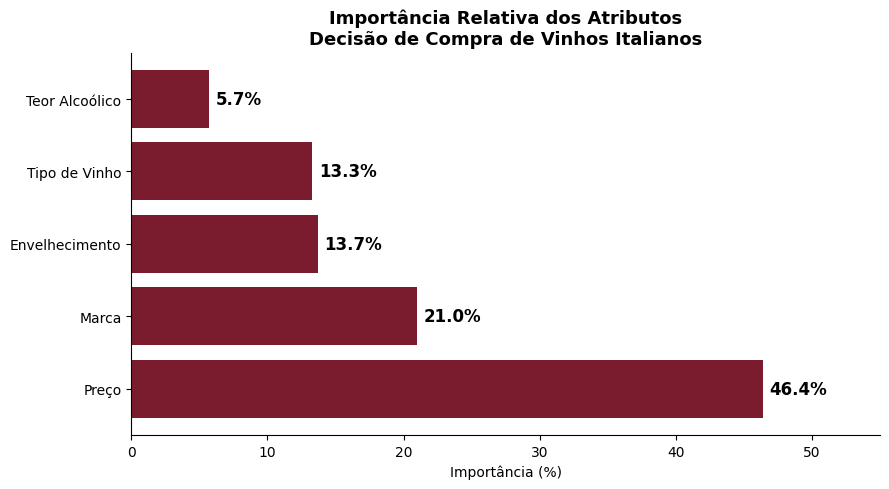

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================
# CALCULAR PART-WORTHS E NÍVEL OMITIDO
# ============================================

# Pegar coeficientes do modelo
coefs = resultado.params

# Função para recuperar o nível omitido (-1 no effects coding)
# O nível omitido = negativo da soma dos outros níveis
def get_partworths(coefs, prefixo):
    niveis = {k: v for k, v in coefs.items() if k.startswith(prefixo)}
    soma = sum(niveis.values())
    nivel_omitido = -soma
    partworths = dict(niveis)
    partworths[prefixo + "omitido"] = nivel_omitido
    return partworths

# Calcular para cada atributo
pw_price    = get_partworths(coefs, "Price_")
pw_brand    = get_partworths(coefs, "Brand_")
pw_type     = get_partworths(coefs, "Type of Wine_")
pw_alcohol  = get_partworths(coefs, "Percentage of Alcohol_")
pw_aging    = get_partworths(coefs, "Aging time of Wine_")

# ============================================
# CALCULAR IMPORTÂNCIA RELATIVA
# ============================================
def importancia(pw_dict):
    valores = list(pw_dict.values())
    return max(valores) - min(valores)

imp_price   = importancia(pw_price)
imp_brand   = importancia(pw_brand)
imp_type    = importancia(pw_type)
imp_alcohol = importancia(pw_alcohol)
imp_aging   = importancia(pw_aging)

total = imp_price + imp_brand + imp_type + imp_alcohol + imp_aging

imp_rel = {
    "Preço":           round(imp_price   / total * 100, 1),
    "Marca":           round(imp_brand   / total * 100, 1),
    "Tipo de Vinho":   round(imp_type    / total * 100, 1),
    "Teor Alcoólico":  round(imp_alcohol / total * 100, 1),
    "Envelhecimento":  round(imp_aging   / total * 100, 1),
}

print("=== IMPORTÂNCIA RELATIVA DOS ATRIBUTOS ===")
for k, v in sorted(imp_rel.items(), key=lambda x: -x[1]):
    print(f"{k}: {v}%")

# ============================================
# GRÁFICO
# ============================================
fig, ax = plt.subplots(figsize=(9, 5))

atribs = list(imp_rel.keys())
vals   = list(imp_rel.values())

# Ordenar do maior para o menor
ordem = sorted(zip(vals, atribs), reverse=True)
vals_ord  = [x[0] for x in ordem]
atribs_ord = [x[1] for x in ordem]

barras = ax.barh(atribs_ord, vals_ord, color="#7a1c2e")

for barra, val in zip(barras, vals_ord):
    ax.text(barra.get_width() + 0.5,
            barra.get_y() + barra.get_height()/2,
            f"{val}%", va="center",
            fontweight="bold", fontsize=12)

ax.set_title("Importância Relativa dos Atributos\nDecisão de Compra de Vinhos Italianos",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Importância (%)")
ax.set_xlim(0, 55)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("importancia_relativa_effects.png", dpi=150)
plt.show()

### gráfico de part-worths 

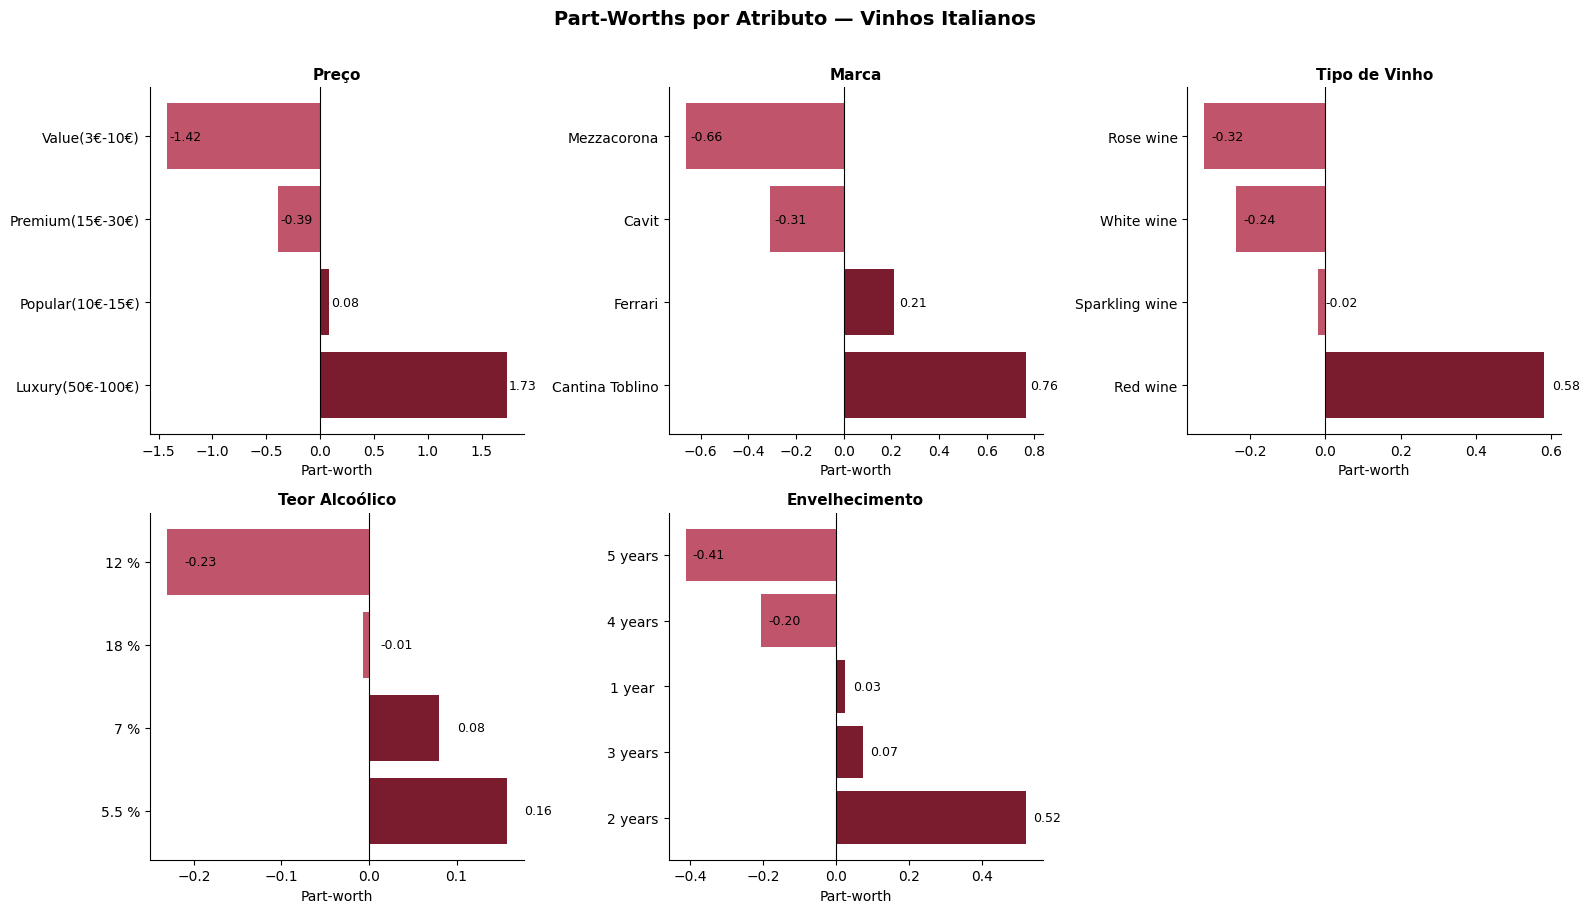

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================
# ORGANIZAR PART-WORTHS COM NOMES CORRETOS
# ============================================

# Recuperar nível omitido de cada atributo
def get_partworths_completo(coefs, prefixo, nome_omitido):
    niveis = {k.replace(prefixo, ""): v 
              for k, v in coefs.items() if k.startswith(prefixo)}
    soma = sum(niveis.values())
    niveis[nome_omitido] = -soma
    return niveis

pw_price = get_partworths_completo(coefs, "Price_", "Value(3€-10€)")
pw_brand = get_partworths_completo(coefs, "Brand_", "Mezzacorona")
pw_type  = get_partworths_completo(coefs, "Type of Wine_", "White wine")
pw_alcohol = get_partworths_completo(coefs, "Percentage of Alcohol_", "7 %")
pw_aging = get_partworths_completo(coefs, "Aging time of Wine_", "5 years")

# ============================================
# PLOTAR GRÁFICO DE PART-WORTHS POR ATRIBUTO
# ============================================

atributos = {
    "Preço":          pw_price,
    "Marca":          pw_brand,
    "Tipo de Vinho":  pw_type,
    "Teor Alcoólico": pw_alcohol,
    "Envelhecimento": pw_aging,
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, (nome, pw) in enumerate(atributos.items()):
    ax = axes[i]
    
    niveis = list(pw.keys())
    valores = list(pw.values())
    
    # Ordenar do maior para o menor
    ordem = sorted(zip(valores, niveis), reverse=True)
    valores_ord = [x[0] for x in ordem]
    niveis_ord  = [x[1] for x in ordem]
    
    # Cores — positivo escuro, negativo claro
    cores = ["#7a1c2e" if v >= 0 else "#c0546a" for v in valores_ord]
    
    barras = ax.barh(niveis_ord, valores_ord, color=cores)
    
    # Valores nas barras
    for barra, val in zip(barras, valores_ord):
        ax.text(barra.get_width() + 0.02,
                barra.get_y() + barra.get_height()/2,
                f"{val:.2f}", va="center", fontsize=9)
    
    ax.axvline(x=0, color="black", linewidth=0.8)
    ax.set_title(nome, fontweight="bold", fontsize=11)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_xlabel("Part-worth")

# Remover subplot vazio
axes[5].set_visible(False)

plt.suptitle("Part-Worths por Atributo — Vinhos Italianos",
             fontsize=14, fontweight="bold", y=1.01)

plt.tight_layout()
plt.savefig("partworths_effects.png", dpi=150, bbox_inches="tight")
plt.show()

### perfil ideal 


=== PERFIL IDEAL DE VINHO ===
Preço: Luxury(50€-100€)
Marca: Cantina Toblino
Tipo de Vinho: Red wine
Teor Alcoólico: 5.5 %
Envelhecimento: 2 years

Utilidade total: 3.753


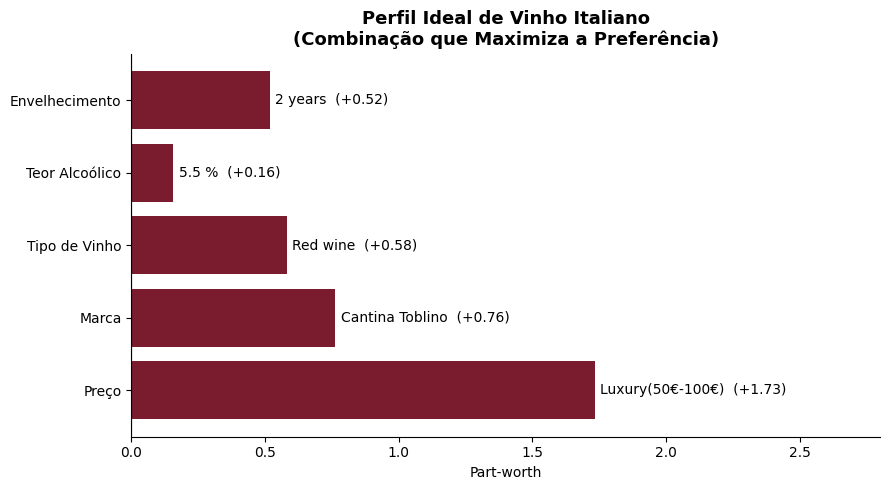

In [8]:
# ============================================
# PERFIL IDEAL
# ============================================

# Pegar o melhor nível de cada atributo
perfil_ideal = {
    "Preço":          max(pw_price, key=pw_price.get),
    "Marca":          max(pw_brand, key=pw_brand.get),
    "Tipo de Vinho":  max(pw_type, key=pw_type.get),
    "Teor Alcoólico": max(pw_alcohol, key=pw_alcohol.get),
    "Envelhecimento": max(pw_aging, key=pw_aging.get),
}

# Calcular utilidade total do perfil ideal
utilidade_ideal = (
    pw_price[perfil_ideal["Preço"]] +
    pw_brand[perfil_ideal["Marca"]] +
    pw_type[perfil_ideal["Tipo de Vinho"]] +
    pw_alcohol[perfil_ideal["Teor Alcoólico"]] +
    pw_aging[perfil_ideal["Envelhecimento"]]
)

print("=== PERFIL IDEAL DE VINHO ===")
for k, v in perfil_ideal.items():
    print(f"{k}: {v}")
print(f"\nUtilidade total: {utilidade_ideal:.3f}")

# ============================================
# GRÁFICO DO PERFIL IDEAL
# ============================================

fig, ax = plt.subplots(figsize=(9, 5))

atribs = list(perfil_ideal.keys())
niveis = list(perfil_ideal.values())
vals   = [
    pw_price[perfil_ideal["Preço"]],
    pw_brand[perfil_ideal["Marca"]],
    pw_type[perfil_ideal["Tipo de Vinho"]],
    pw_alcohol[perfil_ideal["Teor Alcoólico"]],
    pw_aging[perfil_ideal["Envelhecimento"]],
]

barras = ax.barh(atribs, vals, color="#7a1c2e")

# Adicionar nome do nível e valor na barra
for barra, nivel, val in zip(barras, niveis, vals):
    ax.text(barra.get_width() + 0.02,
            barra.get_y() + barra.get_height()/2,
            f"{nivel}  ({val:+.2f})",
            va="center", fontsize=10)

ax.set_title("Perfil Ideal de Vinho Italiano\n(Combinação que Maximiza a Preferência)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Part-worth")
ax.set_xlim(0, 2.8)
ax.axvline(x=0, color="black", linewidth=0.8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("perfil_ideal.png", dpi=150, bbox_inches="tight")
plt.show()

### Cluster

In [10]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# ============================================
# 1. CALCULAR IMPORTÂNCIAS RELATIVAS INDIVIDUAIS
# Abordagem mais estável para amostras pequenas
# ============================================

def calc_importancia_resp(df_resp, df_model, resp_id):
    """Calcula importância relativa por respondente via correlação"""
    mask = df["resp.id"] == resp_id
    df_r = df_model[mask].copy()
    
    atributos = {
        "Price":    [c for c in df_r.columns if c.startswith("Price_")],
        "Brand":    [c for c in df_r.columns if c.startswith("Brand_")],
        "Type":     [c for c in df_r.columns if c.startswith("Type")],
        "Alcohol":  [c for c in df_r.columns if c.startswith("Percentage")],
        "Aging":    [c for c in df_r.columns if c.startswith("Aging")],
    }
    
    importancias = {}
    for nome, cols in atributos.items():
        # Correlação média dos níveis com a escolha
        corrs = [abs(df_r[col].corr(df_r["Choice"])) for col in cols]
        importancias[nome] = np.nanmean(corrs)
    
    # Normalizar para somar 100%
    total = sum(importancias.values())
    if total > 0:
        importancias = {k: v/total*100 for k, v in importancias.items()}
    
    importancias["resp.id"] = resp_id
    return importancias

# Calcular para cada respondente
lista_imp = []
for resp in df["resp.id"].unique():
    imp = calc_importancia_resp(df, df_model, resp)
    lista_imp.append(imp)

df_imp = pd.DataFrame(lista_imp).set_index("resp.id")
print("Importâncias individuais calculadas!")
print(f"Shape: {df_imp.shape}")
print(df_imp.head())
        

Importâncias individuais calculadas!
Shape: (30, 5)
             Price      Brand       Type    Alcohol      Aging
resp.id                                                       
1        30.027392   1.745839  19.577868  24.223110  24.425790
2        19.055556  15.079286  26.921354  34.415010   4.528795
3        34.038948   5.223518  16.642358  13.099423  30.995754
4        24.186215  23.887643  20.837197  22.984753   8.104192
5        24.719122  33.334738   5.893505  24.865506  11.187130


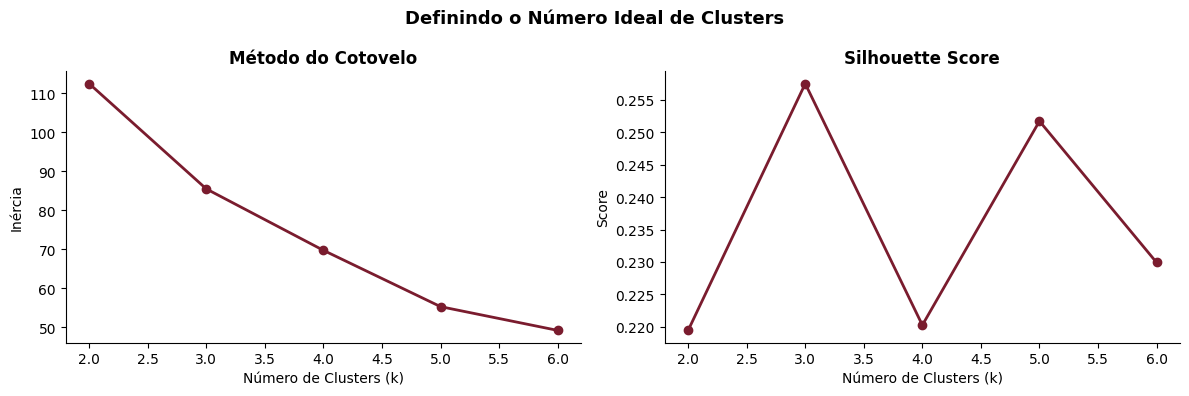


Silhouette scores:
k=2: 0.219
k=3: 0.258
k=4: 0.220
k=5: 0.252
k=6: 0.230


In [11]:
# ============================================
# 2. DEFINIR NÚMERO IDEAL DE CLUSTERS
# Método do Cotovelo + Silhouette
# ============================================

# Padronizar os dados
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_imp)

# Testar de 2 a 6 clusters
inertias = []
silhouettes = []
ks = range(2, 7)

for k in ks:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

# Gráfico
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Cotovelo
axes[0].plot(ks, inertias, "o-", color="#7a1c2e", linewidth=2)
axes[0].set_title("Método do Cotovelo", fontweight="bold")
axes[0].set_xlabel("Número de Clusters (k)")
axes[0].set_ylabel("Inércia")
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# Silhouette
axes[1].plot(ks, silhouettes, "o-", color="#7a1c2e", linewidth=2)
axes[1].set_title("Silhouette Score", fontweight="bold")
axes[1].set_xlabel("Número de Clusters (k)")
axes[1].set_ylabel("Score")
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.suptitle("Definindo o Número Ideal de Clusters",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("clusters_ideal.png", dpi=150)
plt.show()

print("\nSilhouette scores:")
for k, s in zip(ks, silhouettes):
    print(f"k={k}: {s:.3f}")

### 3 Clusters

In [12]:
# ============================================
# 3. RODAR KMEANS COM K=3
# ============================================

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_imp["cluster"] = kmeans.fit_predict(X_scaled)

# Contar respondentes por cluster
print("Respondentes por cluster:")
print(df_imp["cluster"].value_counts().sort_index())

# Perfil médio de cada cluster
perfil_clusters = df_imp.groupby("cluster")[
    ["Price", "Brand", "Type", "Alcohol", "Aging"]
].mean().round(1)

print("\nPerfil médio de cada cluster (importância %):")
print(perfil_clusters)

Respondentes por cluster:
cluster
0    13
1    11
2     6
Name: count, dtype: int64

Perfil médio de cada cluster (importância %):
         Price  Brand  Type  Alcohol  Aging
cluster                                    
0         18.8   20.1  27.0     22.6   11.6
1         38.7   15.8  11.8     24.0    9.7
2         27.4   12.3  14.2     14.4   31.6


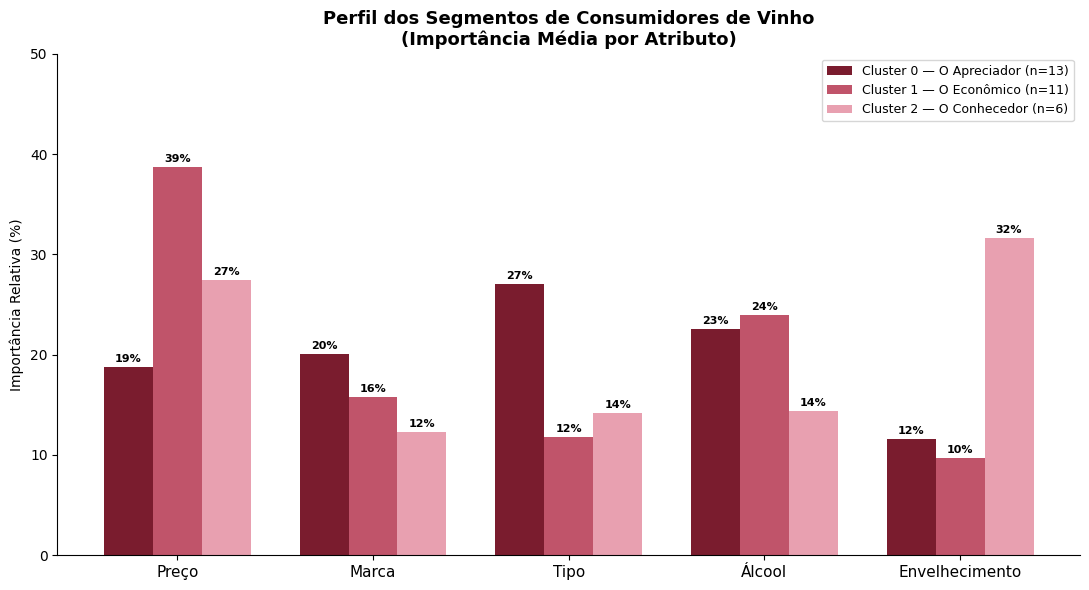

In [13]:
# ============================================
# 4. GRÁFICO DOS CLUSTERS
# ============================================

fig, ax = plt.subplots(figsize=(11, 6))

atribs = ["Price", "Brand", "Type", "Alcohol", "Aging"]
atribs_pt = ["Preço", "Marca", "Tipo", "Álcool", "Envelhecimento"]

x = np.arange(len(atribs_pt))
width = 0.25

cores = ["#7a1c2e", "#c0546a", "#e8a0b0"]
nomes = [
    "Cluster 0 — O Apreciador (n=13)",
    "Cluster 1 — O Econômico (n=11)",
    "Cluster 2 — O Conhecedor (n=6)"
]

for i, (cluster, nome, cor) in enumerate(
        zip([0, 1, 2], nomes, cores)):
    vals = perfil_clusters.loc[cluster, atribs].values
    barras = ax.bar(x + i*width, vals, width,
                    label=nome, color=cor)
    for barra, val in zip(barras, vals):
        ax.text(barra.get_x() + barra.get_width()/2,
                barra.get_height() + 0.5,
                f"{val:.0f}%", ha="center",
                fontsize=8, fontweight="bold")

ax.set_xticks(x + width)
ax.set_xticklabels(atribs_pt, fontsize=11)
ax.set_ylabel("Importância Relativa (%)")
ax.set_title("Perfil dos Segmentos de Consumidores de Vinho\n(Importância Média por Atributo)",
             fontsize=13, fontweight="bold")
ax.legend(loc="upper right", fontsize=9)
ax.set_ylim(0, 50)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("clusters_perfil.png", dpi=150)
plt.show()

Distribuição por sexo:
Sex
Male      17
Female    13
Name: count, dtype: int64

Importância média do Preço:
Feminino: 26.9%
Masculino: 28.5%

Teste Mann-Whitney:
Estatística: 110.000
P-valor: 1.000
❌ Diferença NÃO significativa entre gêneros (p≥0.05)


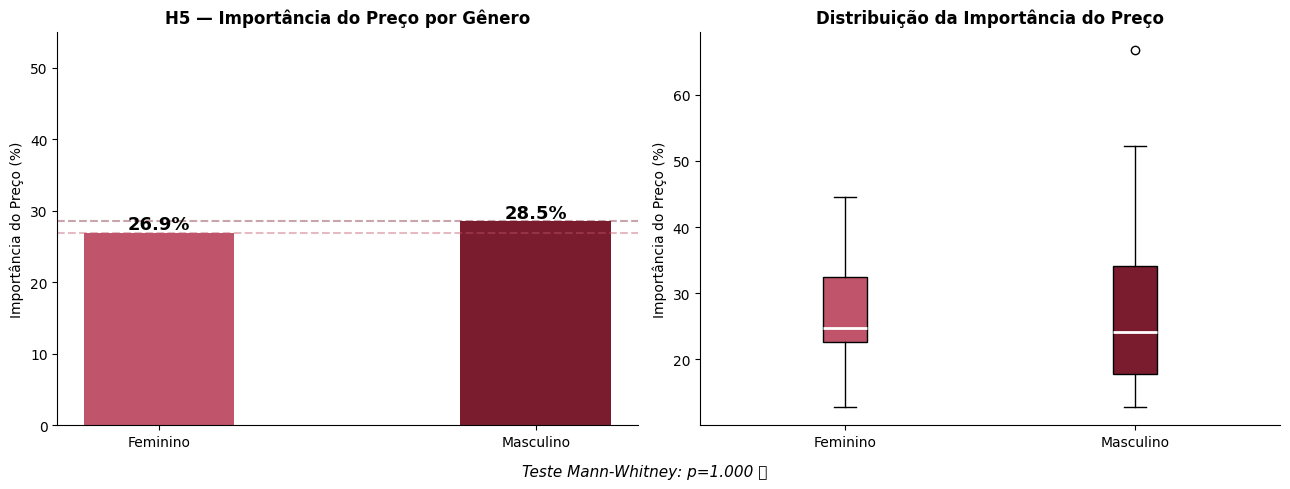

In [15]:
# ============================================
# H5 — IMPORTÂNCIA DO PREÇO POR GÊNERO
# ============================================

# Pegar sexo de cada respondente
# (pegar primeira ocorrência de cada resp.id)
df_sexo = df.groupby("resp.id")["Sex"].first().reset_index()
df_sexo.columns = ["resp.id", "Sex"]

# Juntar com importâncias individuais
df_imp_sexo = df_imp.reset_index().merge(df_sexo, on="resp.id")

print("Distribuição por sexo:")
print(df_imp_sexo["Sex"].value_counts())

# Calcular importância média do preço por sexo
imp_f = df_imp_sexo[df_imp_sexo["Sex"] == "Female"]["Price"].mean().round(1)
imp_m = df_imp_sexo[df_imp_sexo["Sex"] == "Male"]["Price"].mean().round(1)

print(f"\nImportância média do Preço:")
print(f"Feminino: {imp_f}%")
print(f"Masculino: {imp_m}%")

# Teste estatístico — Mann-Whitney
from scipy import stats

grupo_f = df_imp_sexo[df_imp_sexo["Sex"] == "Female"]["Price"]
grupo_m = df_imp_sexo[df_imp_sexo["Sex"] == "Male"]["Price"]

stat, p_valor = stats.mannwhitneyu(grupo_f, grupo_m, 
                                    alternative="two-sided")

print(f"\nTeste Mann-Whitney:")
print(f"Estatística: {stat:.3f}")
print(f"P-valor: {p_valor:.3f}")
if p_valor < 0.05:
    print("✅ Diferença SIGNIFICATIVA entre gêneros (p<0.05)")
else:
    print("❌ Diferença NÃO significativa entre gêneros (p≥0.05)")

# ============================================
# GRÁFICO
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Gráfico 1 — Barras comparando importância do preço
generos = ["Feminino", "Masculino"]
valores = [imp_f, imp_m]
cores = ["#c0546a", "#7a1c2e"]

barras = axes[0].bar(generos, valores, color=cores, width=0.4)
for barra, valor in zip(barras, valores):
    axes[0].text(barra.get_x() + barra.get_width()/2,
                 barra.get_height() + 0.5,
                 f"{valor}%", ha="center",
                 fontweight="bold", fontsize=13)

axes[0].set_title("H5 — Importância do Preço por Gênero",
                  fontsize=12, fontweight="bold")
axes[0].set_ylabel("Importância do Preço (%)")
axes[0].set_ylim(0, 55)
axes[0].axhline(y=imp_f, color="#c0546a", 
                linestyle="--", alpha=0.4)
axes[0].axhline(y=imp_m, color="#7a1c2e", 
                linestyle="--", alpha=0.4)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# Gráfico 2 — Boxplot mostrando distribuição
df_imp_sexo["Sexo"] = df_imp_sexo["Sex"].map(
    {"Female": "Feminino", "Male": "Masculino"})

grupos = [grupo_f.values, grupo_m.values]
bp = axes[1].boxplot(grupos, labels=["Feminino", "Masculino"],
                     patch_artist=True,
                     medianprops=dict(color="white", linewidth=2))

for patch, cor in zip(bp["boxes"], cores):
    patch.set_facecolor(cor)

axes[1].set_title("Distribuição da Importância do Preço",
                  fontsize=12, fontweight="bold")
axes[1].set_ylabel("Importância do Preço (%)")
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

# Adicionar p-valor
sig = "p<0.05 ✅" if p_valor < 0.05 else f"p={p_valor:.3f} ❌"
fig.suptitle(f"Teste Mann-Whitney: {sig}",
             fontsize=11, style="italic", y=0)

plt.tight_layout()
plt.savefig("h5_genero_preco.png", dpi=150)
plt.show()

## simulador de marketshare

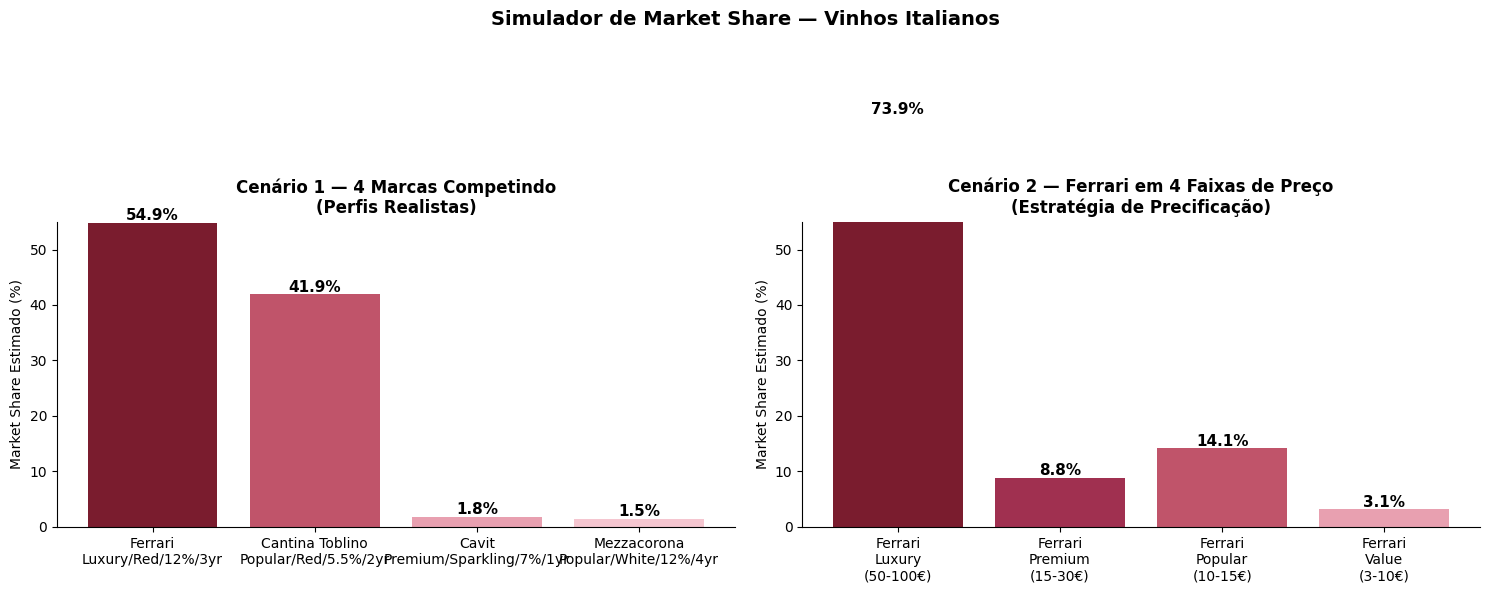


=== CENÁRIO 1 ===
Ferrari Luxury/Red/12%/3yr: 54.9%
Cantina Toblino Popular/Red/5.5%/2yr: 41.9%
Cavit Premium/Sparkling/7%/1yr: 1.8%
Mezzacorona Popular/White/12%/4yr: 1.5%

=== CENÁRIO 2 ===
Ferrari Luxury (50-100€): 73.9%
Ferrari Premium (15-30€): 8.8%
Ferrari Popular (10-15€): 14.1%
Ferrari Value (3-10€): 3.1%


In [18]:
# ============================================
# SIMULADOR DE MARKET SHARE
# ============================================

import numpy as np
import matplotlib.pyplot as plt

# Coeficientes do modelo
coefs = resultado.params

def utilidade_perfil(perfil_dict):
    """
    Calcula a utilidade total de um perfil
    perfil_dict = {"Price": "Luxury(50€-100€)", "Brand": "Ferrari", ...}
    """
    utilidade = 0
    
    mapeamento = {
        "Price":    ("Price_", pw_price,   "Value(3€-10€)"),
        "Brand":    ("Brand_", pw_brand,   "Mezzacorona"),
        "Type":     ("Type of Wine_", pw_type, "White wine"),
        "Alcohol":  ("Percentage of Alcohol_", pw_alcohol, "7 %"),
        "Aging":    ("Aging time of Wine_", pw_aging, "5 years"),
    }
    
    for atrib, (prefixo, pw_dict, omitido) in mapeamento.items():
        nivel = perfil_dict[atrib]
        chave = prefixo + nivel
        if chave in coefs:
            utilidade += coefs[chave]
        else:
            # É o nível omitido — usar o valor calculado
            utilidade += pw_dict[omitido]
    
    return utilidade

def market_share(perfis):
    """
    Calcula market share via modelo logit
    perfis = lista de dicts com atributos de cada produto
    """
    utils = [utilidade_perfil(p) for p in perfis]
    exp_utils = np.exp(utils)
    shares = exp_utils / exp_utils.sum() * 100
    return shares

# ============================================
# DEFINIR CENÁRIOS
# ============================================

# Cenário 1 — 4 marcas competindo com perfil realista
cenario1 = [
    {"Price": "Luxury(50€-100€)", "Brand": "Ferrari",
     "Type": "Red wine",      "Alcohol": "12 %",  "Aging": "3 years"},
    
    {"Price": "Popular(10€-15€)", "Brand": "Cantina Toblino",
     "Type": "Red wine",      "Alcohol": "5.5 %", "Aging": "2 years"},
    
    {"Price": "Premium(15€-30€)", "Brand": "Cavit",
     "Type": "Sparkling wine", "Alcohol": "7 %",  "Aging": "1 year"},
    
    {"Price": "Popular(10€-15€)", "Brand": "Mezzacorona",
     "Type": "White wine",    "Alcohol": "12 %",  "Aging": "4 years"},
]

nomes_c1 = ["Ferrari\nLuxury/Red/12%/3yr",
            "Cantina Toblino\nPopular/Red/5.5%/2yr",
            "Cavit\nPremium/Sparkling/7%/1yr",
            "Mezzacorona\nPopular/White/12%/4yr"]

shares_c1 = market_share(cenario1)

# Cenário 2 — Testando estratégia de preço da Ferrari
cenario2 = [
    {"Price": "Luxury(50€-100€)", "Brand": "Ferrari",
     "Type": "Red wine", "Alcohol": "5.5 %", "Aging": "2 years"},
    
    {"Price": "Premium(15€-30€)", "Brand": "Ferrari",
     "Type": "Red wine", "Alcohol": "5.5 %", "Aging": "2 years"},
    
    {"Price": "Popular(10€-15€)", "Brand": "Ferrari",
     "Type": "Red wine", "Alcohol": "5.5 %", "Aging": "2 years"},
    
    {"Price": "Value(3€-10€)", "Brand": "Ferrari",
     "Type": "Red wine", "Alcohol": "5.5 %", "Aging": "2 years"},
]

nomes_c2 = ["Ferrari\nLuxury\n(50-100€)",
            "Ferrari\nPremium\n(15-30€)",
            "Ferrari\nPopular\n(10-15€)",
            "Ferrari\nValue\n(3-10€)"]

shares_c2 = market_share(cenario2)

# ============================================
# GRÁFICO
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Cenário 1
cores_c1 = ["#7a1c2e", "#c0546a", "#e8a0b0", "#f5c6d0"]
barras1 = axes[0].bar(nomes_c1, shares_c1, color=cores_c1)
for b, v in zip(barras1, shares_c1):
    axes[0].text(b.get_x() + b.get_width()/2,
                 b.get_height() + 0.5,
                 f"{v:.1f}%", ha="center",
                 fontweight="bold", fontsize=11)

axes[0].set_title("Cenário 1 — 4 Marcas Competindo\n(Perfis Realistas)",
                  fontsize=12, fontweight="bold")
axes[0].set_ylabel("Market Share Estimado (%)")
axes[0].set_ylim(0, 55)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# Cenário 2
cores_c2 = ["#7a1c2e", "#a03050", "#c0546a", "#e8a0b0"]
barras2 = axes[1].bar(nomes_c2, shares_c2, color=cores_c2)
for b, v in zip(barras2, shares_c2):
    axes[1].text(b.get_x() + b.get_width()/2,
                 b.get_height() + 0.5,
                 f"{v:.1f}%", ha="center",
                 fontweight="bold", fontsize=11)

axes[1].set_title("Cenário 2 — Ferrari em 4 Faixas de Preço\n(Estratégia de Precificação)",
                  fontsize=12, fontweight="bold")
axes[1].set_ylabel("Market Share Estimado (%)")
axes[1].set_ylim(0, 55)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.suptitle("Simulador de Market Share — Vinhos Italianos",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("market_share.png", dpi=150)
plt.show()

print("\n=== CENÁRIO 1 ===")
for nome, share in zip(nomes_c1, shares_c1):
    print(f"{nome.replace(chr(10), ' ')}: {share:.1f}%")

print("\n=== CENÁRIO 2 ===")
for nome, share in zip(nomes_c2, shares_c2):
    print(f"{nome.replace(chr(10), ' ')}: {share:.1f}%")

  

    